<a href="https://colab.research.google.com/github/gencere757/ARDA-GENCER-DSA210-TERM-PROJECT/blob/Obesity-Data/DSA210_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Filtering, Cleaning And Transforming The Data
## 1.1 Importing the necessary libraries


In [71]:
import pandas as pd
import numpy as np

## 1.2 Obesity Rate Data
  Here, the obesity rate data were made into a dataframe, the empty or NaN values were cleared, and a seperate column for log values were added since they will be needed to apply log transform when plotting later.

In [72]:
foodDF = pd.read_csv('StateAndCountyData.csv')
obesityDF = foodDF[foodDF['Variable_Code'] == "PCT_OBESE_ADULTS22"]
obesityDF = obesityDF[obesityDF['Value']>0].copy()
obesityDF

,FIPS,State,County,Variable_Code,Value
374301,1001.0,AL,Autauga,PCT_OBESE_ADULTS22,38.3
374312,1003.0,AL,Baldwin,PCT_OBESE_ADULTS22,38.3
374323,1005.0,AL,Barbour,PCT_OBESE_ADULTS22,38.3
374334,1007.0,AL,Bibb,PCT_OBESE_ADULTS22,38.3
374345,1009.0,AL,Blount,PCT_OBESE_ADULTS22,38.3
...,...,...,...,...,...
408830,56037.0,WY,Sweetwater,PCT_OBESE_ADULTS22,34.3
408841,56039.0,WY,Teton,PCT_OBESE_ADULTS22,34.3
408852,56041.0,WY,Uinta,PCT_OBESE_ADULTS22,34.3
408863,56043.0,WY,Washakie,PCT_OBESE_ADULTS22,34.3


## 1.3 The Walkability Index Data
Here, the walkability index data was extracted from its .csv file.

In [73]:
walkDF = pd.read_csv('WalkabilityIndexByCounty.csv')
walkDF

,Unnamed: 0,GEOID10,NatWalkInd,County
0,1,1001,5.234375,Autauga
1,2,1003,6.450355,Baldwin
2,3,1005,5.188406,Barbour
3,4,1007,5.033333,Bibb
4,5,1009,4.666667,Blount
...,...,...,...,...
1897,3607,72139,4.865079,Trujillo Alto
1898,3609,72143,4.015152,Vega Alta
1899,3611,72145,4.450450,Vega Baja
1900,3614,72149,3.254902,Villalba


## 1.4 Fast Food Restaurants Per 1000 People
The data was extracted from the .csv file, the empty rows were cleaned and log transformation was applied to data since the distribution here was mostly right-skewed.

In [74]:
restaurantDF = foodDF[foodDF['Variable_Code'] == "FFRPTH20"]   #Fast food restaurants per 1000 people in county
restaurantDF = restaurantDF[restaurantDF['Value']>0].copy()
restaurantDF['Log_Transformed_Restaurants'] = np.log1p(restaurantDF['Value'])
restaurantDF

,FIPS,State,County,Variable_Code,Value,Log_Transformed_Restaurants
728093,1001.0,AL,Autauga,FFRPTH20,0.801496,0.588618
728105,1003.0,AL,Baldwin,FFRPTH20,0.750152,0.559702
728117,1005.0,AL,Barbour,FFRPTH20,0.976046,0.681098
728129,1007.0,AL,Bibb,FFRPTH20,0.316227,0.274769
728141,1009.0,AL,Blount,FFRPTH20,0.414658,0.346888
...,...,...,...,...,...,...
765725,56031.0,WY,Platte,FFRPTH20,0.466309,0.382748
765737,56033.0,WY,Sheridan,FFRPTH20,0.680426,0.519048
765761,56037.0,WY,Sweetwater,FFRPTH20,0.609285,0.475790
765773,56039.0,WY,Teton,FFRPTH20,0.680938,0.519352


## 1.5 Combining  The Data Into A Single Data Frame

In [75]:
walkSubset = walkDF[['GEOID10', 'NatWalkInd']].copy()
walkSubset = walkSubset.rename(columns={
    'GEOID10': 'FIPS',
    'NatWalkInd': 'Walkability_Index'
})

restSubset = restaurantDF[['FIPS', 'Value', 'Log_Transformed_Restaurants']].copy()
restSubset = restSubset.rename(columns={
    'Value': 'Fast_Food_Per_1000',
    'Log_Transformed_Restaurants': 'Log_Fast_Food'
})

obeseSubset = obesityDF[['FIPS', 'Value']].copy()
obeseSubset = obeseSubset.rename(columns={
    'Value': 'Obesity_Rate'
})

combinedDF = walkSubset.merge(obeseSubset, on='FIPS', how='inner') \
                       .merge(restSubset, on='FIPS', how='inner')
combinedDF = combinedDF.dropna()
combinedDF

,FIPS,Walkability_Index,Obesity_Rate,Fast_Food_Per_1000,Log_Fast_Food
0,1001,5.234375,38.3,0.801496,0.588618
1,1003,6.450355,38.3,0.750152,0.559702
2,1005,5.188406,38.3,0.976046,0.681098
3,1007,5.033333,38.3,0.316227,0.274769
4,1009,4.666667,38.3,0.414658,0.346888
...,...,...,...,...,...
1672,56005,7.333333,34.3,0.642729,0.496359
1673,56013,6.763441,34.3,0.559554,0.444400
1674,56021,7.887255,34.3,0.626274,0.486291
1675,56025,8.940972,34.3,0.631071,0.489237


# 2. Data Visualizations

## 2.1 Graphs, Correlation, Preliminary Analysis

### 2.1.1 Importing The Necessary Libraries

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

### 2.1.1 Getting The General Statistical Information About The Data

In [77]:
combinedDF.describe()

,FIPS,Walkability_Index,Obesity_Rate,Fast_Food_Per_1000,Log_Fast_Food
count,1677.000000,1677.000000,1677.000000,1677.000000,1677.000000
mean,28599.777579,7.137120,34.838462,0.694503,0.516197
std,16036.389020,2.342961,3.549965,0.291989,0.143567
min,1001.000000,1.000000,24.300000,0.165298,0.152977
25%,16069.000000,5.607843,33.200000,0.537661,0.430262
50%,28033.000000,6.462867,35.200000,0.678763,0.518057
75%,42039.000000,7.903846,37.700000,0.807698,0.592054
max,56033.000000,15.957258,41.000000,6.684492,2.039204


### 2.1.2 Plotting The Walkability Index Data As A Histogram

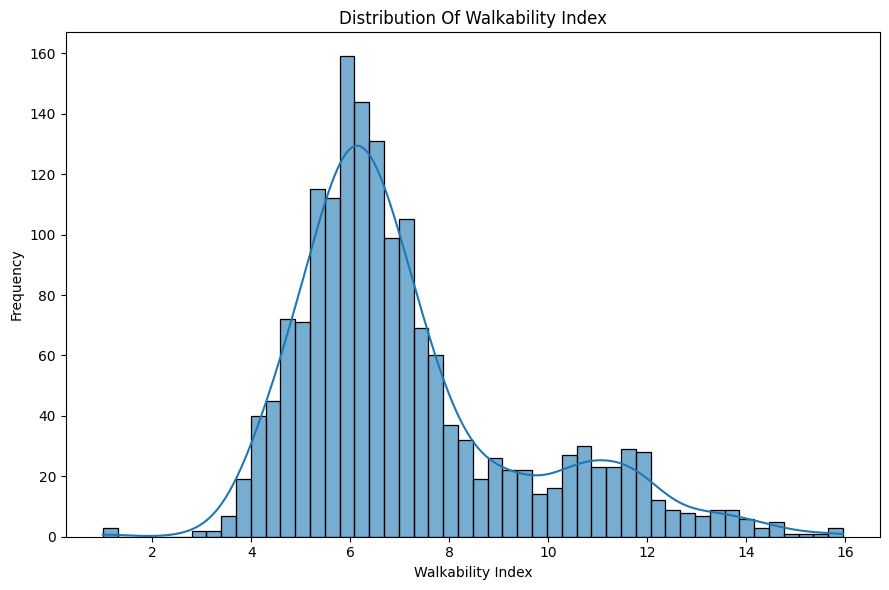

In [78]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Walkability_Index'],bins=50,kde=True,alpha=0.6)
plt.title("Distribution Of Walkability Index")
plt.xlabel("Walkability Index")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.1.3 Plotting The Fast Food Restaurant Data As A Histogram

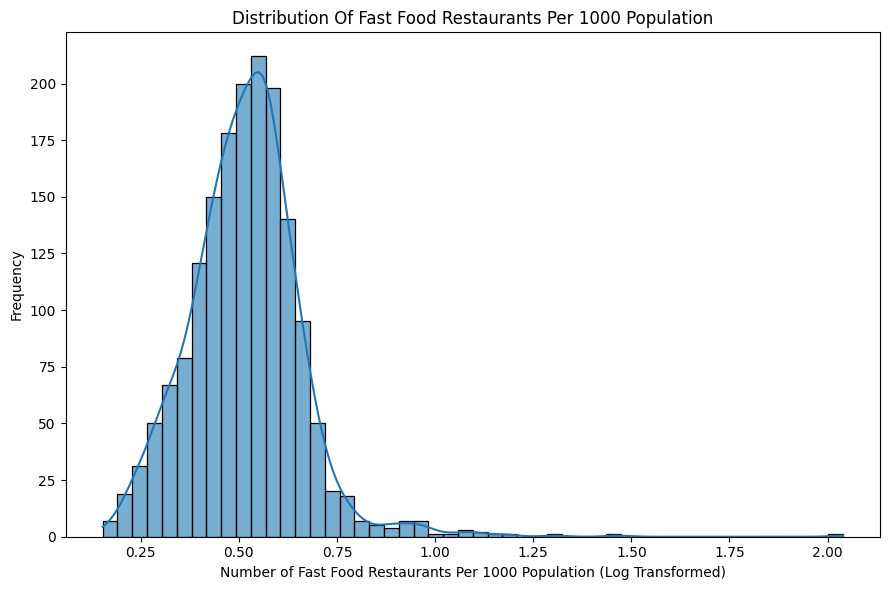

In [79]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Log_Fast_Food'],bins=50,kde=True,alpha=0.6)
plt.title("Distribution Of Fast Food Restaurants Per 1000 Population")
plt.xlabel("Number of Fast Food Restaurants Per 1000 Population (Log Transformed)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.1.2 Plotting The Obesity Rate Data As A Histogram

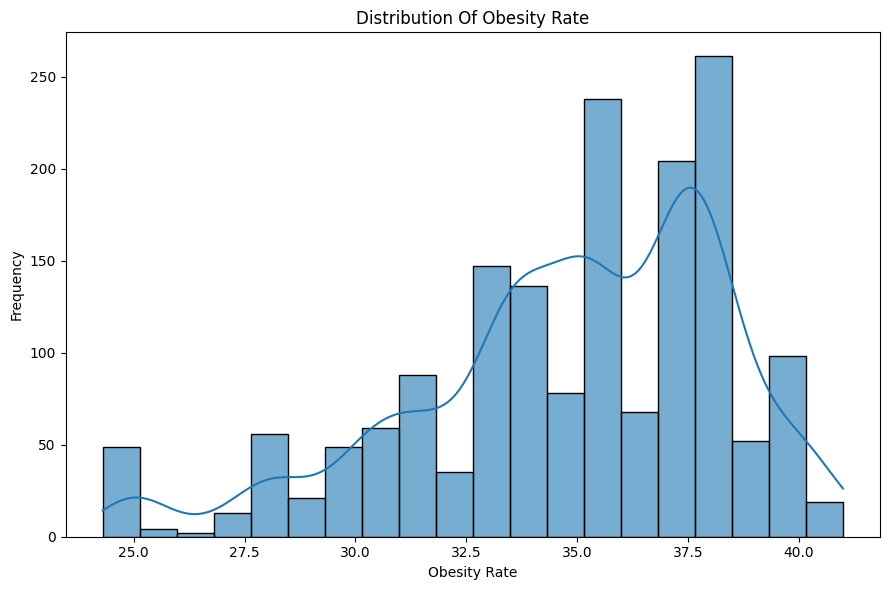

In [80]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Obesity_Rate'],bins=20,kde=True,alpha=0.6)
plt.title("Distribution Of Obesity Rate")
plt.xlabel("Obesity Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

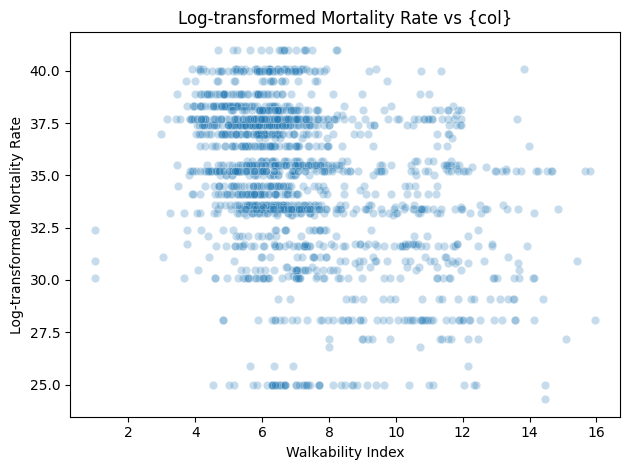

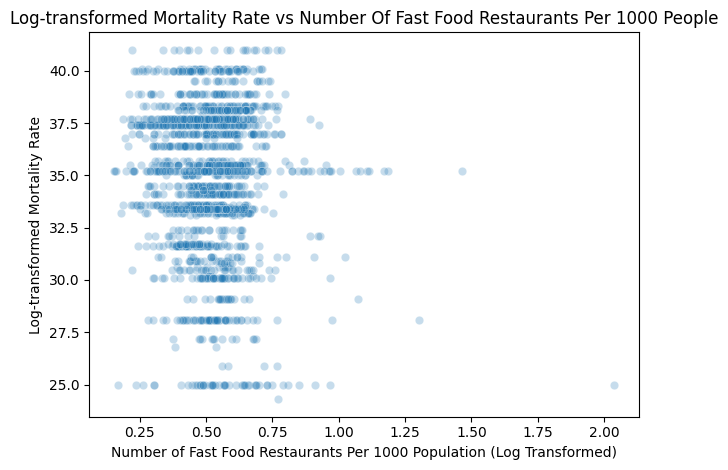

In [81]:
sns.scatterplot(x=combinedDF['Walkability_Index'], y=combinedDF['Obesity_Rate'],alpha=0.25)
plt.title('Log-transformed Mortality Rate vs {col}')
plt.xlabel('Walkability Index')
plt.ylabel('Log-transformed Mortality Rate')
plt.tight_layout()
plt.show()

sns.scatterplot(x=combinedDF['Log_Fast_Food'], y=combinedDF['Obesity_Rate'],alpha=0.25)
plt.title('Log-transformed Mortality Rate vs Number Of Fast Food Restaurants Per 1000 People')
plt.xlabel('Number of Fast Food Restaurants Per 1000 Population (Log Transformed)')
plt.ylabel('Log-transformed Mortality Rate')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

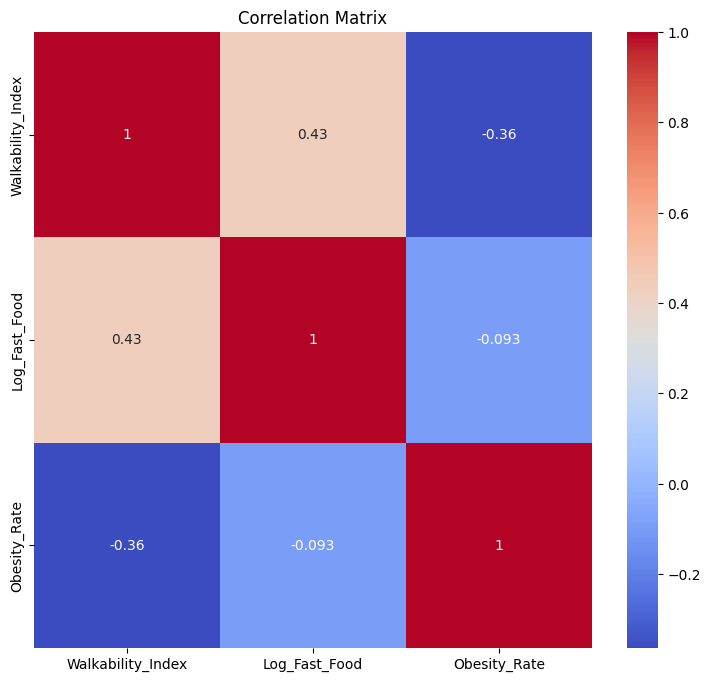

In [82]:
plt.figure(figsize=(9, 8))
sns.heatmap(combinedDF[['Walkability_Index', 'Log_Fast_Food', 'Obesity_Rate']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

## 2.2 Mapping The Data

In [83]:
import plotly.express as px
import plotly.graph_objects as go

In [84]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Obesity_Rate',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Obesity_Rate': 'Obesity_Rate'},
    title='US County-Level Data Visualization'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()

In [85]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Walkability_Index',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Walkability_Index': 'Walkability_Index'},
    title='US County-Level Data Visualization'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()

In [86]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Log_Fast_Food',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Log_Fast_Food': 'Log_Fast_Food'},
    title='US County-Level Data Visualization'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()